# DBSCAN

For this practical we will be considering a dataset containing the credit card usage behavior of about 9000 active credit card holders during a 6 month period. 

We will use DBSCAN to cluster the activity and see if it corresponds to groups of spending types. 


### The data dictionary

The data contains 18 variables being the following:

| Variable                       | Description                                                                                                                 |
|--------------------------------|-----------------------------------------------------------------------------------------------------------------------------|
| CUSTID                         | Identification of Credit Card holder (Categorical)                                                                          |
| BALANCE                        | Balance amount left in their account to make purchases                                                                      |
| BALANCEFREQUENCY               | How frequently the balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)           |
| PURCHASES                      | Amount of purchases made from account                                                                                       |
| ONEOFFPURCHASES                | Maximum purchase amount done in one-go                                                                                      |
| INSTALLMENTSPURCHASES          | Amount of purchase done in installment                                                                                      |
| CASHADVANCE                    | Cash in advance given by the user                                                                                           |
| PURCHASESFREQUENCY             | How frequently the purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased) |
| ONEOFFPURCHASESFREQUENCY       | How frequently purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)                   |
| PURCHASESINSTALLMENTSFREQUENCY | How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)                      |
| CASHADVANCEFREQUENCY           | How frequently the cash in advance is being paid                                                                            |
| CASHADVANCETRX                 | Number of transactions made with "Cash in Advance"                                                                          |
| PURCHASESTRX                   | Number of purchase transcations made                                                                                        |
| CREDITLIMIT                    | Limit of credit card for user                                                                                               |
| PAYMENTS                       | Amount of payments made by the user                                                                                         |
| MINIMUM_PAYMENTS               | Minumum amount of the payments made by the user                                                                             |
| PRCFULLPAYMENT                 | Percentage of full payments which has been paid by the user                                                                 |
| TENURE                         | Tenure of credit card service for the user                                                                                  |

Source is [here](https://www.kaggle.com/arjunbhasin2013/ccdata).

In [1]:
# Import the necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances

# Turn off pink warnings

import warnings
warnings.filterwarnings('ignore')

## 1) Load and transform the data


Read the data contained in `data/CC GENERAL.csv` into a pandas dataframe called `df`, whilst also dropping the column called `CUST_ID`. Then take a look at the data (via the `.head`) method to check the formatting.

In [2]:
df = pd.read_csv("data/CC GENERAL.csv").drop('CUST_ID', axis=1)
print(df.shape)
df.head()


(8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


Check if there are null values in the data using the function `isnull()`.

In [3]:
df.isnull().sum()


BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

We find that there are some missing values but it is a very small proportion of the dataset and only present in 2 columns. Therefore, drop the rows with missing values and store this in `df`.

In [4]:
# Handling the missing values 
df.dropna(inplace=True)


We can now check the data type for each column and confirm that it is as expected.

In [5]:
# Check the data types
df.dtypes


BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

## 2) Explore the data

Using the `describe` function, explore the statistical properties of the dataset. By considering the 75th percentile and the maximum values, what can we say about certain columns of the data?

In [6]:
df.describe()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000
mean,1601.224893,0.895035,1025.433874,604.901438,420.843533,994.175523,0.496000,0.205909,0.368820,0.137604,3.313918,15.033233,4522.091030,1784.478099,864.304943,0.159304,11.534391
std,2095.571300,0.207697,2167.107984,1684.307803,917.245182,2121.458303,0.401273,0.300054,0.398093,0.201791,6.912506,25.180468,3659.240379,2909.810090,2372.566350,0.296271,1.310984
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.049513,0.019163,0.000000,6.000000
25%,148.095189,0.909091,43.367500,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,418.559237,169.163545,0.000000,12.000000
50%,916.855459,1.000000,375.405000,44.995000,94.785000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,896.675701,312.452292,0.000000,12.000000
75%,2105.195853,1.000000,1145.980000,599.100000,484.147500,1132.385490,0.916667,0.333333,0.750000,0.250000,4.000000,18.000000,6500.000000,1951.142090,825.496463,0.166667,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


There are large outliers in the columns: `BALANCE`, `PURCHASES`, `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`, `CASH_ADVANCE`, `CREDIT_LIMIT`, `PAYMENTS` and `MINIMUM_PAYMENTS`. We can see this by approximately considering if the maximum or minimum values are more than the mean plus/minus twice the standard deviation.

Therefore we will fit the DBSCAN model to the full dataset and scale our data to handle the skew. As an extension, we later consider a simple approach to handle this by dividing the data into categories. 

Extension: [This](https://towardsdatascience.com/a-brief-overview-of-outlier-detection-techniques-1e0b2c19e561) is a good article on common outlier detection techniques. The z-score provides an easy way to quickly identify possible outliers, however note that it does assume a normal distribution for your data.

## 3) Scaling the data for clustering

Remember that when considering the distance between points it is important to scale the data. This is so that we don't increase the importance of variables which have larger values by nature. 

For this dataset we will rescale the data using the following steps:

1) Using `StandardScaler`, rescale the data and save it in a variable called `scaled_data`.
    Hint: For this define a `StandardScaler` object and use it with the `fit_transform` function on our dataframe. Store the scaled data as `scaled_data`.
  
2) Convert `scaled_data` to a pandas dataframe with the same columns as `df`. Store this as `scaled_df`.

In [7]:
# 1) Scale the data to bring all the attributes to a comparable level 
scaler = StandardScaler() 
scaled_data = scaler.fit_transform(df) 

# 2) Converting to a pandas DataFrame 
scaled_df = pd.DataFrame(scaled_data, columns=df.columns) 


Let us quickly check that the `StandardScaler` has worked by using `describe` to check the new means and standard deviations. Our scaled data should now have a mean of zero (or as close as a machine can get!) and a standard deviation of 1. 

In [8]:
scaled_df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8636.000000,8.636000e+03,8.636000e+03,8.636000e+03,8.636000e+03,8.636000e+03,8.636000e+03,8.636000e+03,8.636000e+03,8.636000e+03,8.636000e+03,8.636000e+03,8.636000e+03,8.636000e+03,8.636000e+03,8.636000e+03,8.636000e+03
mean,0.000000,-3.159430e-16,-1.053143e-16,-1.974644e-17,-3.291073e-17,7.240361e-17,8.227683e-18,-2.632859e-17,-5.759378e-17,1.645537e-17,1.810090e-17,-1.316429e-17,1.053143e-16,-3.949288e-17,6.582147e-18,6.582147e-17,9.215005e-17
std,1.000058,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00,1.000058e+00
min,-0.764144,-4.309583e+00,-4.732082e-01,-3.591603e-01,-4.588390e-01,-4.686555e-01,-1.236139e+00,-6.862796e-01,-9.265216e-01,-6.819525e-01,-4.794369e-01,-5.970542e-01,-1.222207e+00,-6.132812e-01,-3.643042e-01,-5.377269e-01,-4.221800e+00
25%,-0.693469,6.767893e-02,-4.531953e-01,-3.591603e-01,-4.588390e-01,-4.686555e-01,-1.028455e+00,-6.862796e-01,-9.265216e-01,-6.819525e-01,-4.794369e-01,-5.573385e-01,-7.985975e-01,-4.694457e-01,-2.930083e-01,-5.377269e-01,3.551807e-01
50%,-0.326598,5.054046e-01,-2.999696e-01,-3.324445e-01,-3.554965e-01,-4.686555e-01,9.968862e-03,-4.085365e-01,-5.078338e-01,-6.819525e-01,-4.794369e-01,-3.190448e-01,-4.159823e-01,-3.051243e-01,-2.326108e-01,-5.377269e-01,3.551807e-01
75%,0.240507,5.054046e-01,5.562856e-02,-3.444604e-03,6.901931e-02,6.515234e-02,1.048393e+00,4.246962e-01,9.575697e-01,5.570222e-01,9.925796e-02,1.178270e-01,5.405558e-01,5.727990e-02,-1.635812e-02,2.485496e-02,3.551807e-01
max,8.323708,5.054046e-01,2.215714e+01,2.384284e+01,2.407255e+01,2.175188e+01,1.256077e+00,2.646651e+00,1.585600e+00,6.751896e+00,1.731543e+01,1.362114e+01,6.963026e+00,1.681891e+01,3.184159e+01,2.837758e+00,3.551807e-01


## 4) Investigate a starting value for eps

Measure the distance of each point to its closest neighbor. To do this, use the function `sklearn.metrics.pairwise.pairwise_distances` on the scaled dataset, `scaled_df`. Let the output of `pairwise_distances` be stored as `all_distances`, and store the list of neighbour distances as `neig_distances`.

Note that the documentation is given [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise_distances.html).

In [9]:
# Compute all the pairwise distances
all_distances = pairwise_distances(scaled_df, metric='euclidean')

# Compute the distance of each point to its closest neighbor
neig_distances = [np.min(row[np.nonzero(row)]) for row in all_distances]


Plot the distribution of the distances using the function `hist`. Use enough bins to clearly see the behaviour at the tail, around 100-200 should be sufficient. 

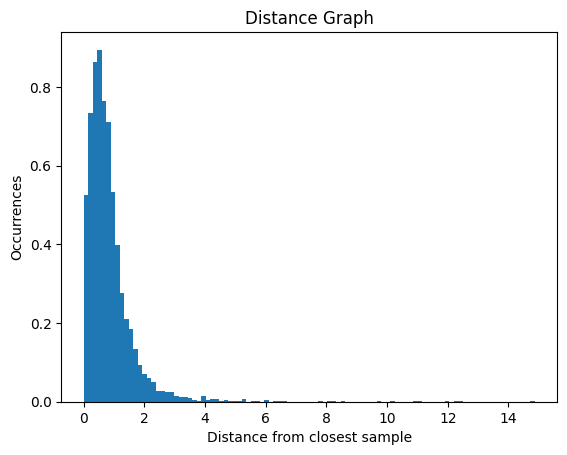

In [10]:
# Plot the distances
plt.hist(neig_distances, bins=100, density=True);
plt.xlabel('Distance from closest sample')
plt.ylabel('Occurrences')
plt.title('Distance Graph')
plt.show()


Looking at your graph what distances look appropriate for eps? Remember we want to choose a value slightly higher than the optimal one and then revise it down, so we'll choose an intial value to the right of the distribution. 

## 5) Principal Component Analysis (PCA) of data

Initially we will just use these two principal components to easily plot the data, however later in the exercise we will also explore how we can apply DBSCAN to them directly. 

Get the first 2 principal components of the data. To do this, use the function `PCA` to create a `pca` object and then use the `fit_transform` function to apply it to the scaled data. Store the result in a dataframe called `X_principal` with columns `P1` and `P2`. 

In [11]:
pca = PCA(n_components = 2) 
X_principal = pca.fit_transform(scaled_df)

X_principal = pd.DataFrame(X_principal) 
X_principal.columns = ['P1', 'P2'] 
X_principal.head()


,P1,P2
0,-1.696395,-1.122584
1,-1.215681,2.435638
2,0.935853,-0.385202
3,-1.614638,-0.724586
4,0.223701,-0.783610


## 6) Fit the DBSCAN model 

Apply DBSCAN, starting with `eps=2` and `min_samples=34` using the functions `DBSCAN` and `fit_predict`, storing the output as `cluster_assignment`. Then print out the unique clusters found. Note that the cluster labelled as `-1` are identified as noise/outliers by the DBSCAN model.

Remember to apply the function to `scaled_df`. You can be explicit in specifying the columns of interest by using `.iloc[0:17]`. This is so that if adding columns containing the cluster assignments to our dataframe, we don't include them in any modelling later on.

Note: We start with `eps=2` as this sits toward the right tail of our histogram of distances so this is a suitable first choice. We start with `min_samples=34` as a good rule of thumb is to start with twice the number of features, here ` 2 x 17`, this can then be increased if needed. 

In [12]:
db = DBSCAN(eps=2, min_samples=34)  
cluster_assignment = db.fit_predict(scaled_df.iloc[:,0:17])

print(np.unique(cluster_assignment))


[-1  0]


Assign a column called `labels` to `scaled_df` containing the cluster assignment

In [13]:
scaled_df['labels'] = cluster_assignment


Create a scatter plot with `x=X_principal['P1']` and `y=X_principal['P2']` and set the colour parameter `c=cluster_assignment`. Also change the size of the points using `s=3`, this will make it clearer to see the dense regions.

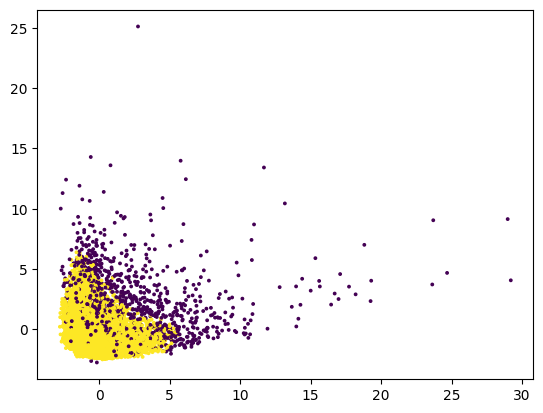

In [14]:
plt.scatter(x=X_principal['P1'], y=X_principal['P2'], c=cluster_assignment, s=3);
plt.show()


We can see that our model has captured one cluster and termed the remaining points as noise. These two groups seem to overlap when we visualise them using the first two principle components, why do you think this is?

We can now explore the distribution of each variable for each of the clusters identified. Use the below code to explore these properties and see what conclusions we can make about each cluster. 

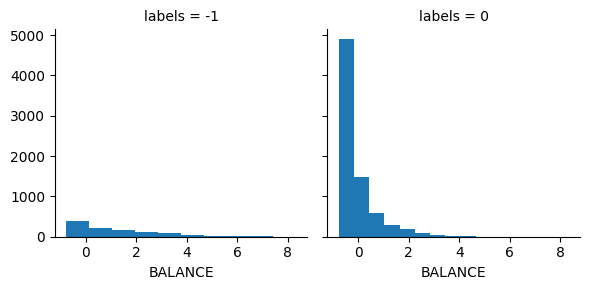

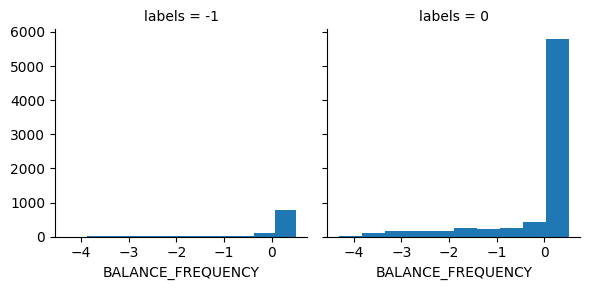

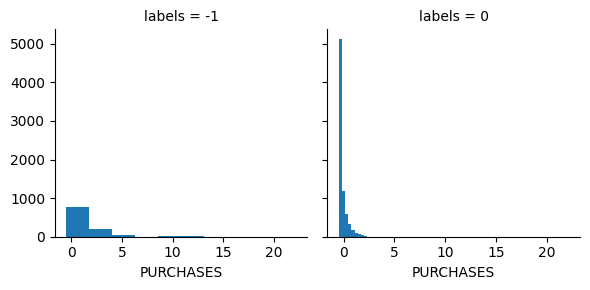

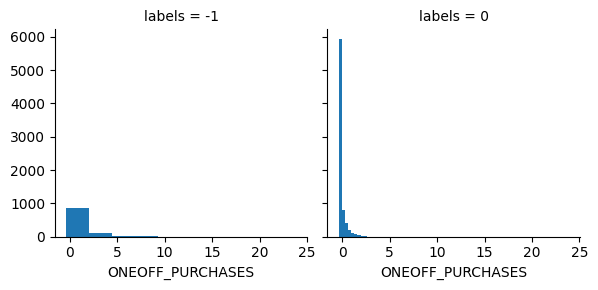

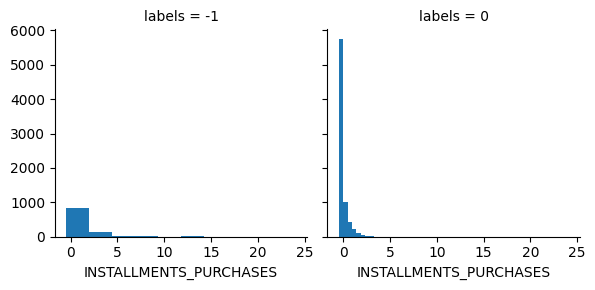

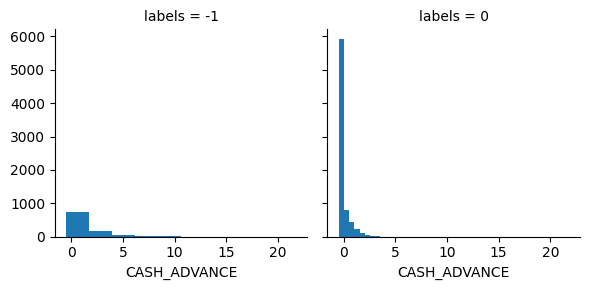

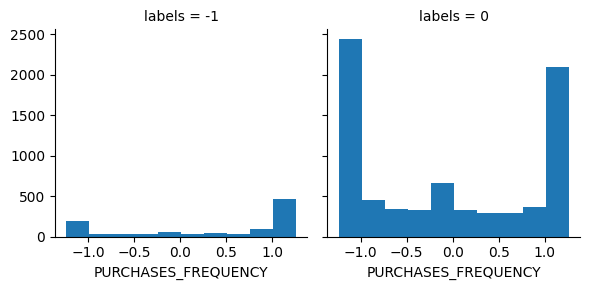

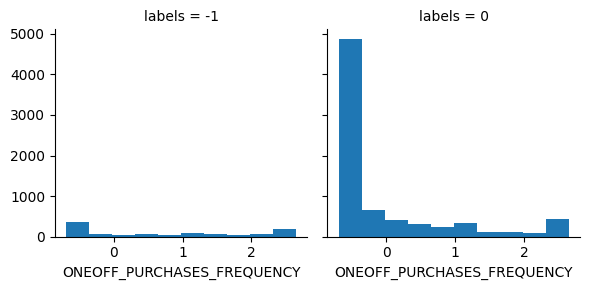

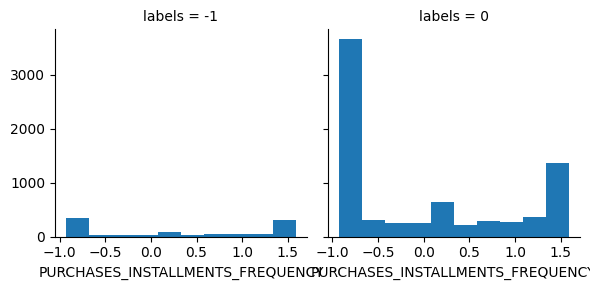

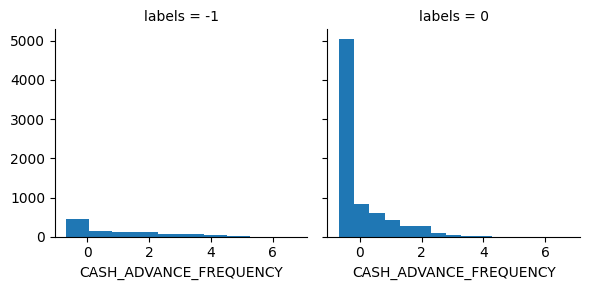

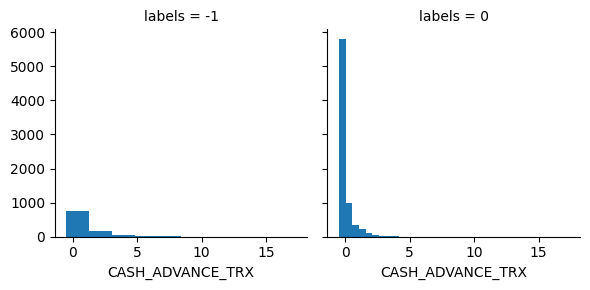

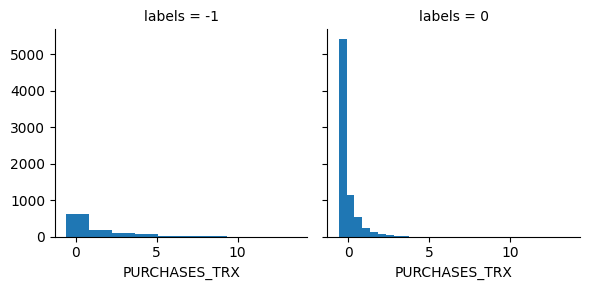

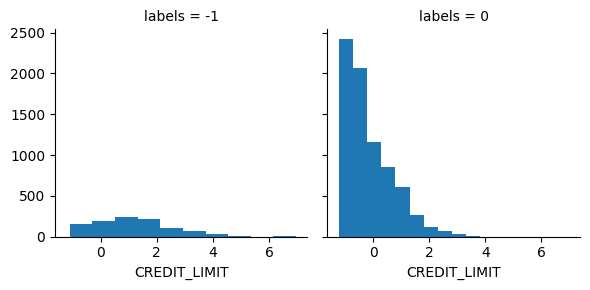

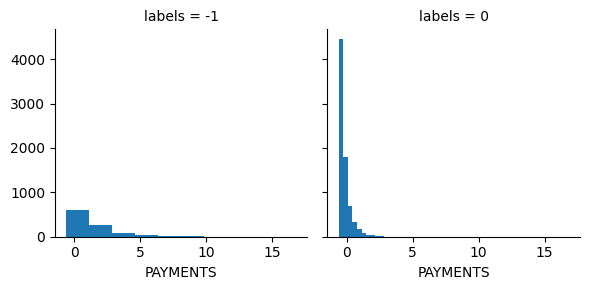

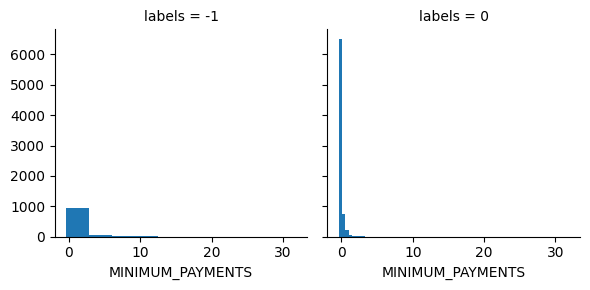

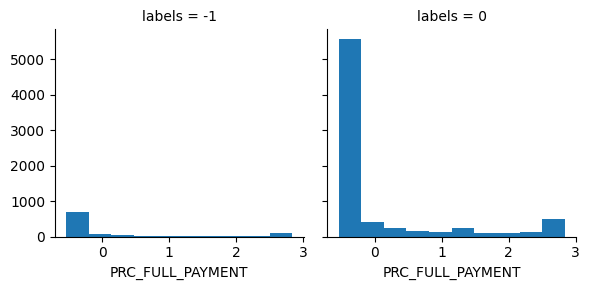

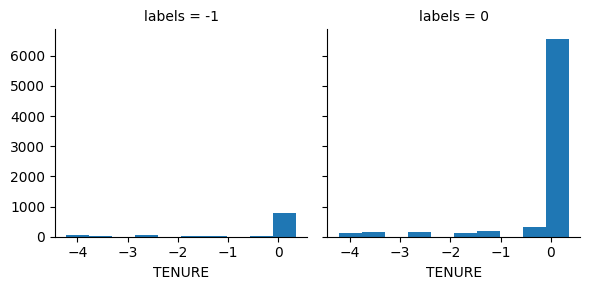

In [15]:
for c in scaled_df.iloc[:,0:17]:
    grid= sns.FacetGrid(scaled_df, col='labels')
    grid.map(plt.hist, c)


It looks like the non-noise cluster corresponds to a specific type of customer behaviour. This could be used in several key ways including seeing if an anomalous payment was made by a customer based on their behaviour cluster. Alternatively on a business level, different marketing strategies can be pitched to each group in order to maximise results. 

Specifically for this clustering outcome we find that: 

Cluster 0: Customers with a typically low one-off purchase frequency and consistently high tenure. 

Note: this clustering was produced using our initial guesses of `eps=2` and `min_samples=34`. As we've done nothing to tune these values they're likely not optimal and probably don't accurately represent the underlying patterns or groups within the data.

## 7) Additional modelling

We can also consider running DBSCAN on the PCA components. To do this run the same DBSCAN as previously but on the dataset `X_principal` using the same values for `eps` and `min_samples` and store the output once again in `cluster_assignment`.

Then print out the unique clusters

In [16]:
db = DBSCAN(eps = 2, min_samples = 34).fit(X_principal)
cluster_assignment = db.fit_predict(X_principal)

print(np.unique(cluster_assignment))


[-1  0]


Plot the results with the new cluster assignment. As before, create a scatter plot of the principal components, coloured by the new cluster assignment.

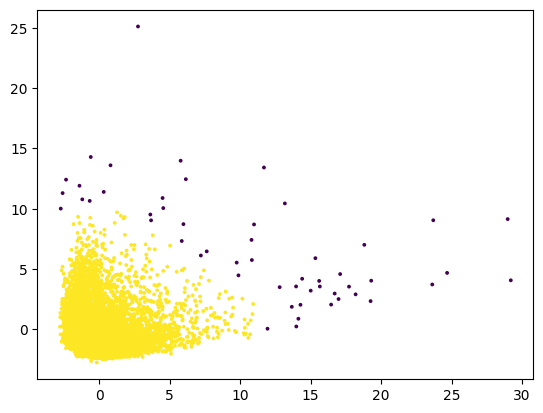

In [17]:
plt.scatter(x=X_principal['P1'], y=X_principal['P2'], c=cluster_assignment, s=3);
plt.show()


Then plot the distribution of the results to identify the interpretation of each cluster in terms of the credit card user's behaviour. To do this: 

1) Assign the new cluster assignment to a column of `scaled_df` called `pca_labels`. 

2) Then copy the code used previously for the distributional plots, changing the `col` parameter to be the new `pca_labels`.

In [18]:
scaled_df['pca_labels'] = cluster_assignment


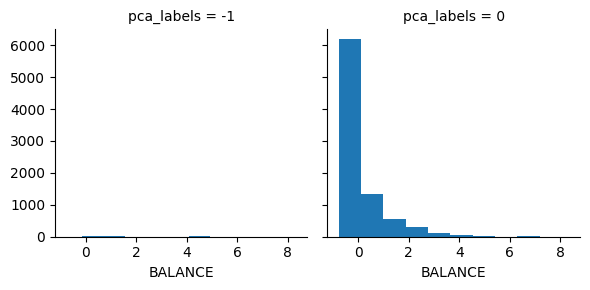

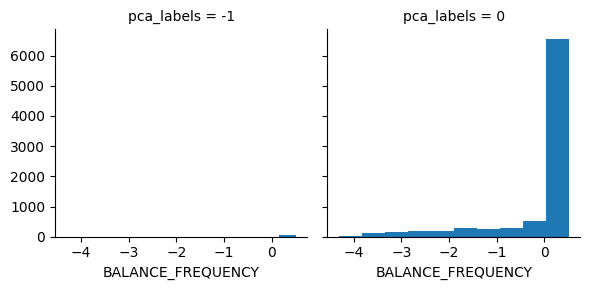

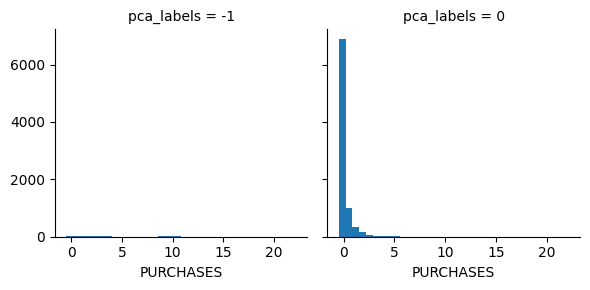

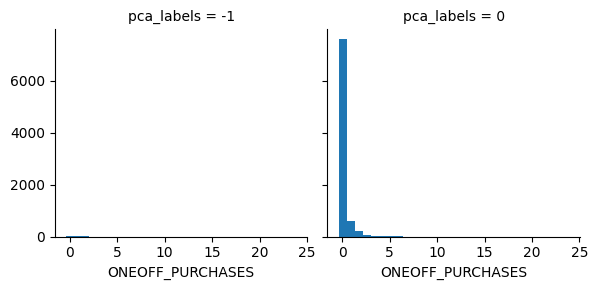

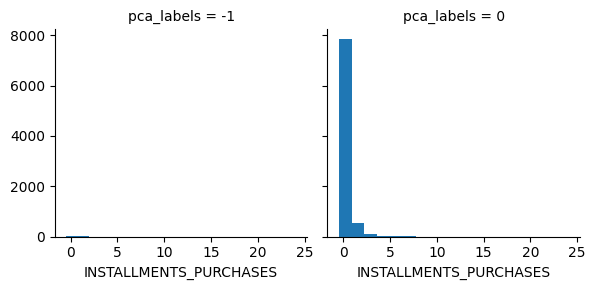

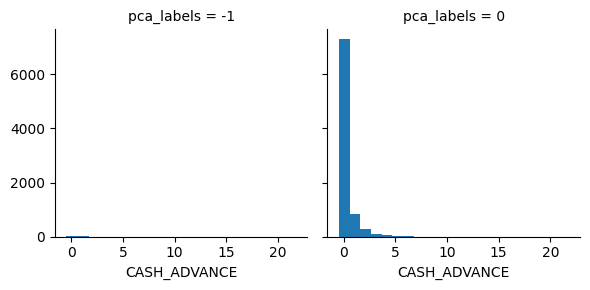

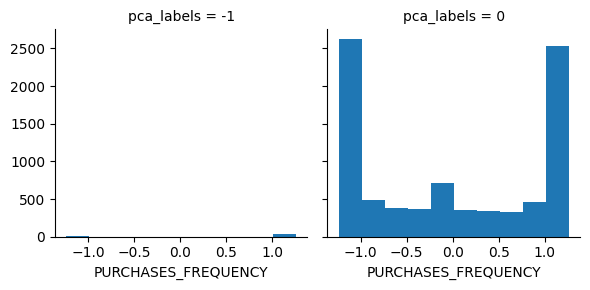

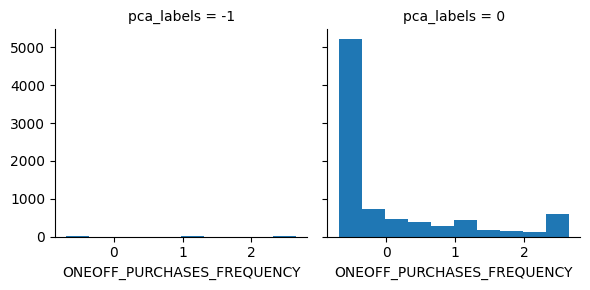

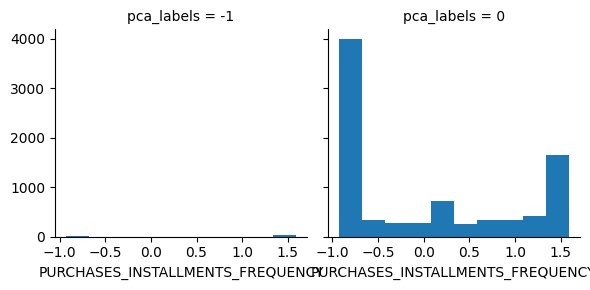

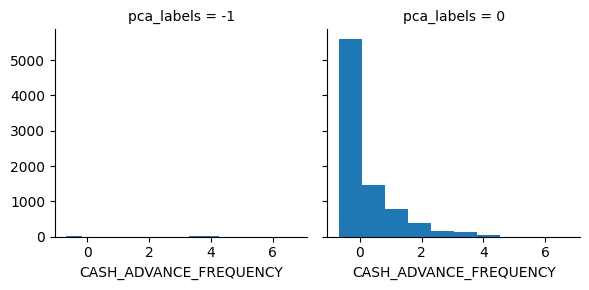

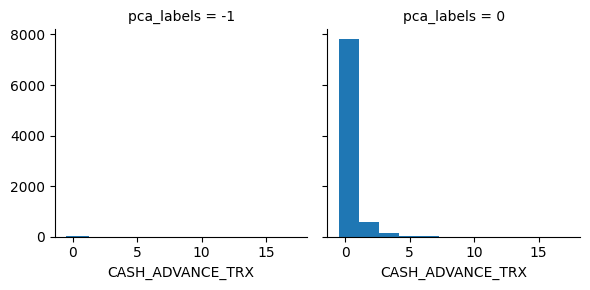

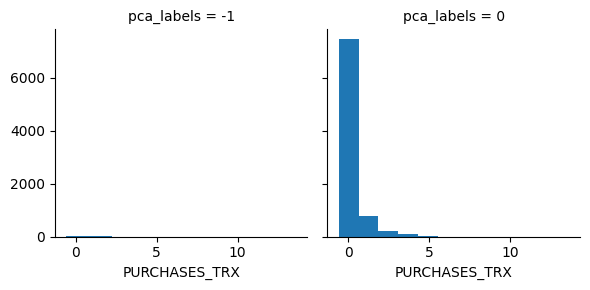

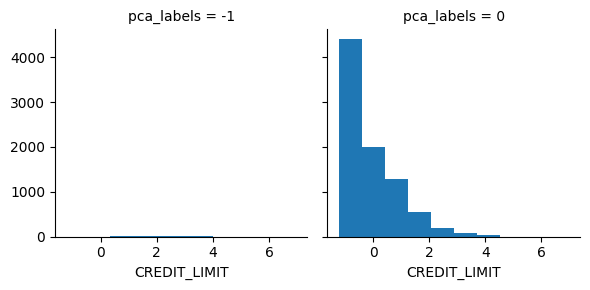

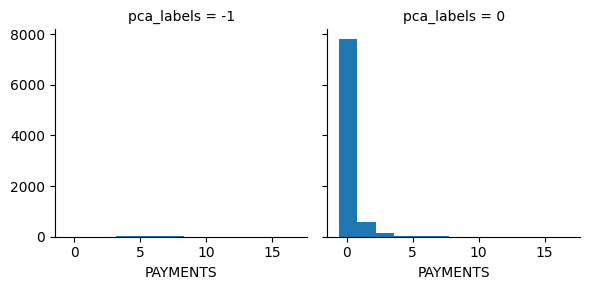

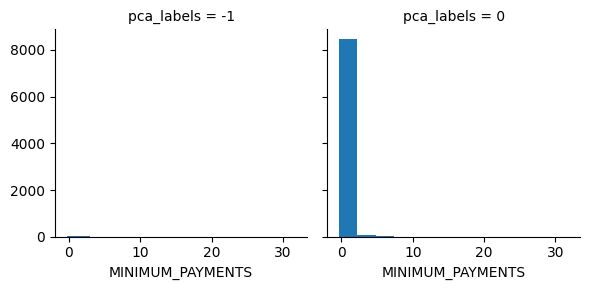

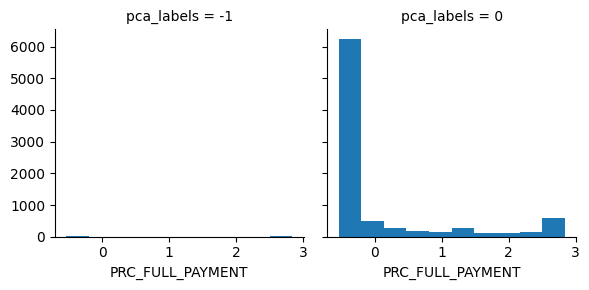

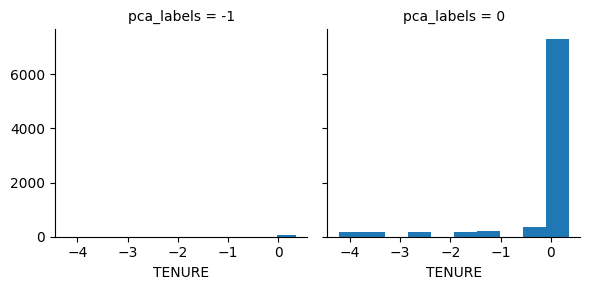

In [19]:
for c in scaled_df.iloc[:,0:17]:
    grid= sns.FacetGrid(scaled_df, col='pca_labels')
    grid.map(plt.hist, c)


This time nearly all of the points have been assigned to the cluster with very few points being classed as outliers. Even though our model hyperparameters have remained the same our output has changed, this is because the modelling was perfomed on the 2 dimensional PCA data space which is denser. Why do you think the PCA space is denser than the original space? How might we change our `eps` and `min_values` given that we've moved to a denser space?

## Extension: Handling skewed data

As noticed previously, there are large outliers in the columns: `BALANCE`, `PURCHASES`, `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`, `CASH_ADVANCE`, `CREDIT_LIMIT`, `PAYMENTS` and `MINIMUM_PAYMENTS`.

We are interested in finding similarities through clusters so it is helpful to group values in these columns with large outliers to categories. We'll then replace the category labels with the median value of each category, this allows us to preserve some information while (hopefully!) removing skew. 

Visualise this by first plotting the distribution of `df['PURCHASES']` using the `hist` function.

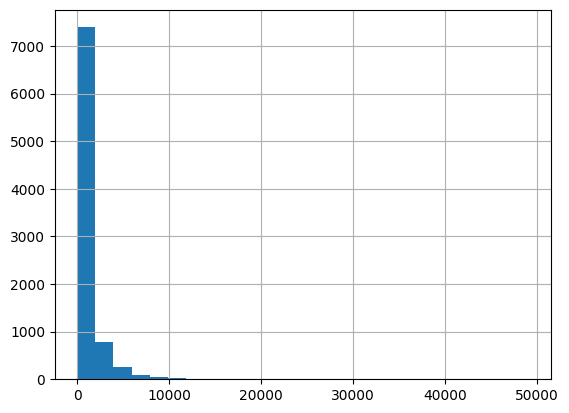

In [20]:
df['PURCHASES'].hist(bins = 25);


Print the maximum value in the column `Purchases`.

In [21]:
print(df['PURCHASES'].max())


49039.57


As we can see, there is a very large spread of values. Therefore first create a copy of `df` and name it `categorical_df`.

In [22]:
categorical_df = df.copy()


Run the below code to convert the columns listed to categories. The new columns will be stored in columns with the same name, but with `_MEDIAN` appended. 

In [23]:
columns=['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
                'PAYMENTS', 'MINIMUM_PAYMENTS']

categorical_df = df.copy()

for c in columns:

    Range=c+'_MEDIAN'
    categorical_df[Range]=0        
    categorical_df.loc[((categorical_df[c]>0)&(categorical_df[c]<=500)),Range]=1
    categorical_df.loc[((categorical_df[c]>500)&(categorical_df[c]<=1000)),Range]=2
    categorical_df.loc[((categorical_df[c]>1000)&(categorical_df[c]<=3000)),Range]=3
    categorical_df.loc[((categorical_df[c]>3000)&(categorical_df[c]<=5000)),Range]=4
    categorical_df.loc[((categorical_df[c]>5000)&(categorical_df[c]<=10000)),Range]=5
    categorical_df.loc[((categorical_df[c]>10000)),Range]=6

Run the below code to replace each category with the median value from the original column.

Note: `c[:-7]]` removes the "_MEDIAN" from our column names allowing us to access the original column.

In [24]:
for c in categorical_df.columns[-len(columns):]:
    for i in range(1, 7):
        col_median = categorical_df.loc[categorical_df[c]==i, c[:-7]].median()
        categorical_df.loc[categorical_df[c]==i, c] = col_median

categorical_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PRC_FULL_PAYMENT,TENURE,BALANCE_MEDIAN,PURCHASES_MEDIAN,ONEOFF_PURCHASES_MEDIAN,INSTALLMENTS_PURCHASES_MEDIAN,CASH_ADVANCE_MEDIAN,CREDIT_LIMIT_MEDIAN,PAYMENTS_MEDIAN,MINIMUM_PAYMENTS_MEDIAN
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,...,0.000000,12,88.570138,219.385,0.000,219.100,0.000000,1000,284.847952,181.773223
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,...,0.222222,12,3822.477096,0.000,0.000,0.000,6448.247202,7000,3789.993246,1509.468577
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,...,0.000000,12,1620.495541,702.400,715.550,0.000,0.000000,7000,698.817652,691.692633
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,...,0.000000,12,776.752698,219.385,178.815,0.000,0.000000,2000,698.817652,181.773223
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,...,0.000000,12,1620.495541,1608.970,0.000,1477.695,0.000000,2000,1606.934143,1509.468577


We can check how the summary statistics have changed by using `describe` on the transformed data and original data.

In [25]:
categorical_df.iloc[:,-len(columns):].describe()

,BALANCE_MEDIAN,PURCHASES_MEDIAN,ONEOFF_PURCHASES_MEDIAN,INSTALLMENTS_PURCHASES_MEDIAN,CASH_ADVANCE_MEDIAN,CREDIT_LIMIT_MEDIAN,PAYMENTS_MEDIAN,MINIMUM_PAYMENTS_MEDIAN
count,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000
mean,1508.811768,943.389088,559.345726,398.219474,944.512156,4294.986105,1666.934552,777.001945
std,1950.581902,1643.848651,1380.168450,836.720725,1842.582669,3220.793633,2295.587288,1710.231306
min,0.000000,0.000000,0.000000,0.000000,0.000000,500.000000,284.847952,181.773223
25%,88.570138,219.385000,0.000000,0.000000,0.000000,2000.000000,284.847952,181.773223
50%,776.752698,219.385000,178.815000,219.100000,0.000000,2000.000000,698.817652,181.773223
75%,1620.495541,1608.970000,715.550000,219.100000,1772.796822,7000.000000,1606.934143,691.692633
max,11702.223205,12717.255000,14605.990000,12550.925000,12405.294500,12500.000000,13733.557830,15914.484620


In [26]:
categorical_df[columns].describe()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
count,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000
mean,1601.224893,1025.433874,604.901438,420.843533,994.175523,4522.091030,1784.478099,864.304943
std,2095.571300,2167.107984,1684.307803,917.245182,2121.458303,3659.240379,2909.810090,2372.566350
min,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.049513,0.019163
25%,148.095189,43.367500,0.000000,0.000000,0.000000,1600.000000,418.559237,169.163545
50%,916.855459,375.405000,44.995000,94.785000,0.000000,3000.000000,896.675701,312.452292
75%,2105.195853,1145.980000,599.100000,484.147500,1132.385490,6500.000000,1951.142090,825.496463
max,19043.138560,49039.570000,40761.250000,22500.000000,47137.211760,30000.000000,50721.483360,76406.207520


As expected the max values for each column have been reduced while the means have remained mostly the same. 

Then drop the columns given by the list `columns` from the dataframe `categorical_df`.

In [27]:
categorical_df = categorical_df.drop(columns, axis = 1)


Check that we have the same number of features in our transformed dataframe as in our original by comparing the `shape`.

In [28]:
print(categorical_df.shape)
print(df.shape)


(8636, 17)
(8636, 17)


As previously, we can now scale the data contained in `categorical_df`. Store the result in `scaled_cat_df`.

In [29]:
# 1) Scale the data to bring all the attributes to a comparable level 
scaler = StandardScaler() 
scaled_cat_data = scaler.fit_transform(categorical_df) 

# 2) Converting to a pandas DataFrame 
scaled_cat_df = pd.DataFrame(scaled_cat_data, columns=categorical_df.columns) 


Compute the first two principal components of the data contained in `scaled_cat_df` and save this in a dataframe called `X_cat_principal`. You can see the first rows using the `head` function. We'll use this to plot our new clusters.

In [30]:
pca = PCA(n_components = 2) 
X_cat_principal = pca.fit_transform(scaled_cat_df.iloc[:,0:17])

X_cat_principal = pd.DataFrame(X_cat_principal) 
X_cat_principal.columns = ['P1', 'P2'] 
X_cat_principal.head()


,P1,P2
0,-1.621949,-1.297179
1,-1.392141,2.828109
2,0.953710,-0.463014
3,-1.510049,-0.825742
4,0.487885,-0.763428


Find a starting value for eps by using the distribution of pairwise distances of the principal component dataframe `X_principal` and plot the results as a histogram. 

In [31]:
# Compute all the pairwise distances
all_distances = pairwise_distances(scaled_cat_df, metric='euclidean')

# Compute the distance of each point to its closest neighbor
neig_distances = [np.min(row[np.nonzero(row)]) for row in all_distances]


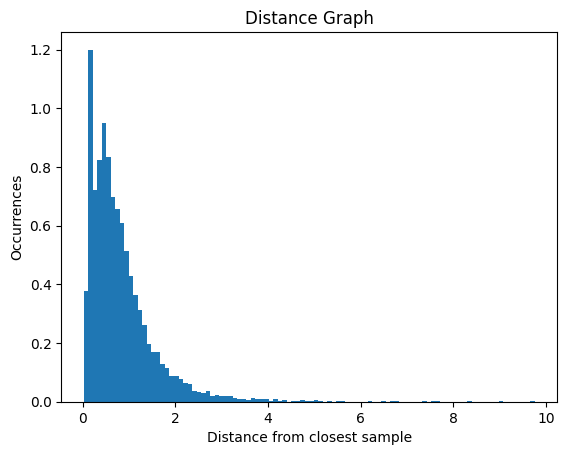

In [32]:
# Plot the distances
plt.hist(neig_distances, bins=100, density=True);
plt.xlabel('Distance from closest sample')
plt.ylabel('Occurrences')
plt.title('Distance Graph')
plt.show()


Starting with `eps=1.1` and `min_samples=34`, run the DBSCAN algorithm on `scaled_cat_df` and print out the unique numbers of clusters.

In [33]:
db = DBSCAN(eps=1.1, min_samples=34)
cluster_assignment = db.fit_predict(scaled_cat_df)

print(np.unique(cluster_assignment))


[-1  0  1  2  3  4]


Run `value_counts` on a Series containing the `cluster_assignment`. Does this look like a more promising clustering attempt?

In [34]:
pd.Series(cluster_assignment).value_counts()


-1    4563
 0    3794
 2     137
 4      58
 3      54
 1      30
Name: count, dtype: int64

Plot the result in a scatter plot of the principal components and coloured by the clustering assignment.

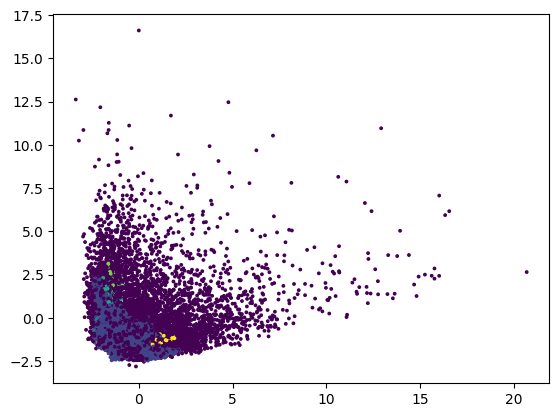

In [35]:
plt.scatter(x=X_cat_principal['P1'], y=X_cat_principal['P2'], c=cluster_assignment,s=3);
plt.show()


Finally use the below code to explore the results and interpretation of each cluster. You can toggle the `eps` and `min_samples` parameters to see how the clusters can vary both visually and distributionally. 

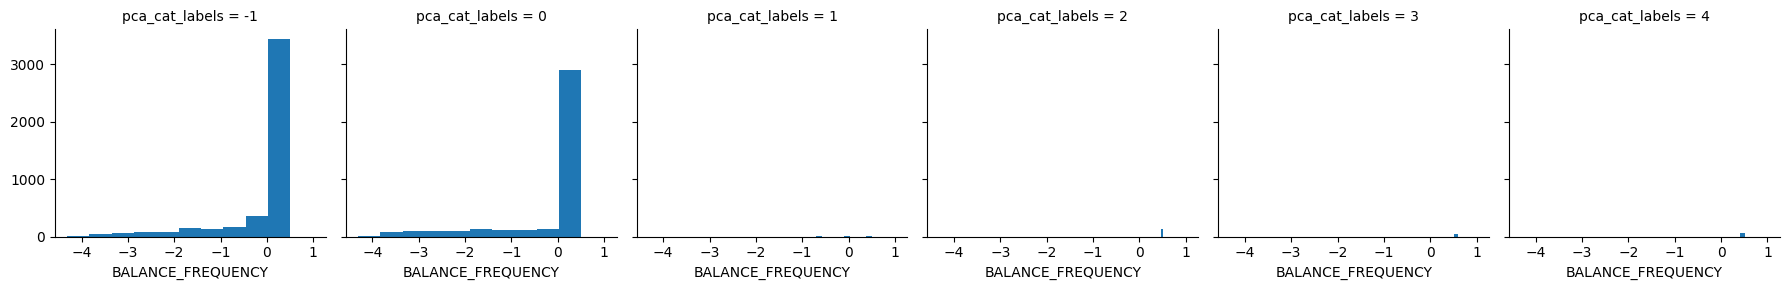

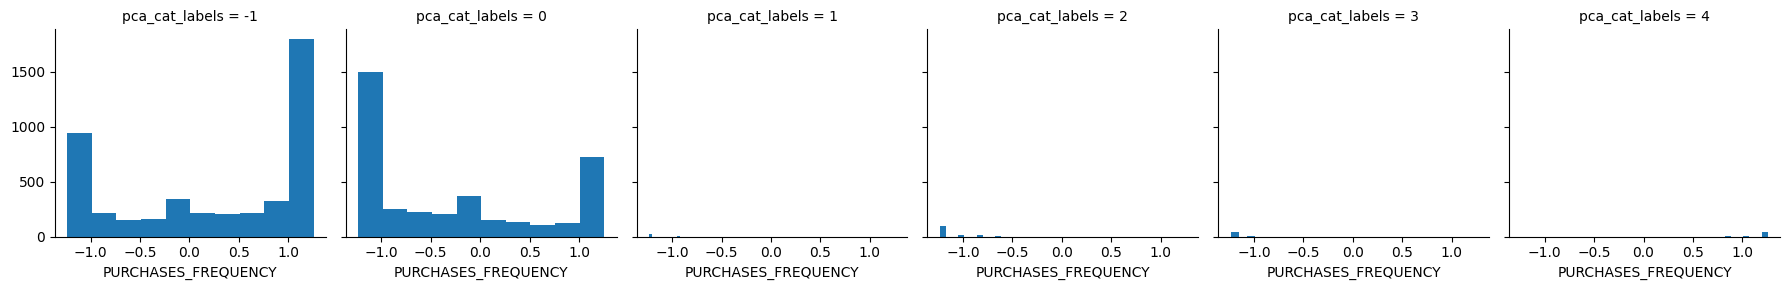

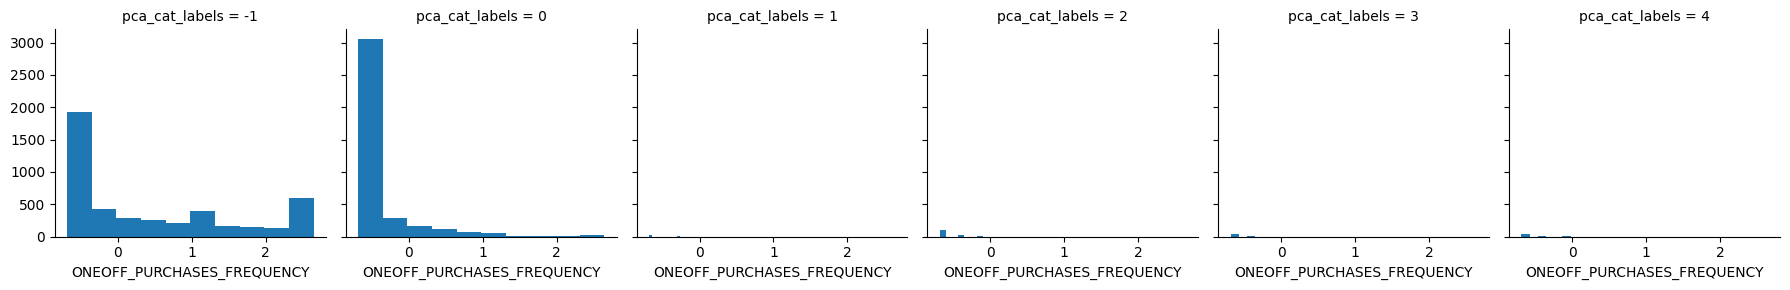

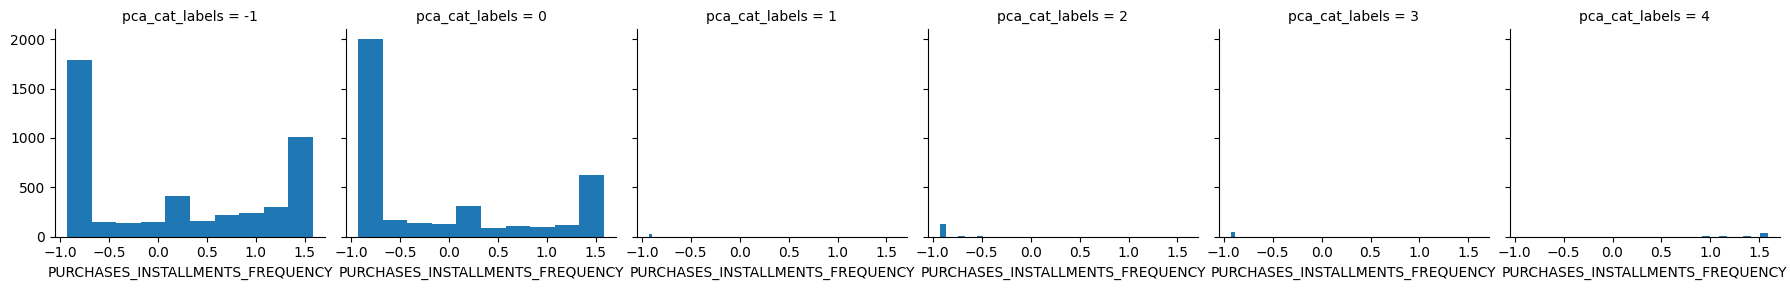

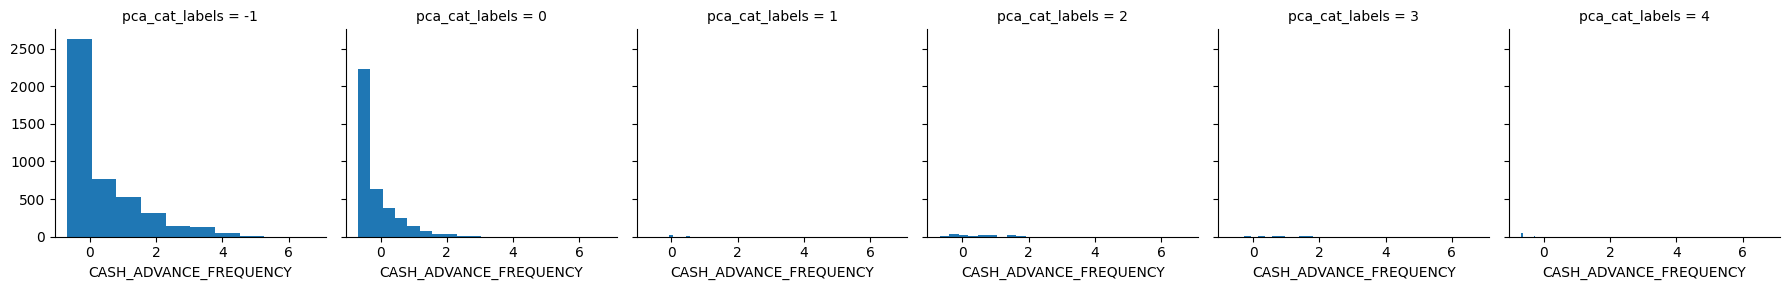

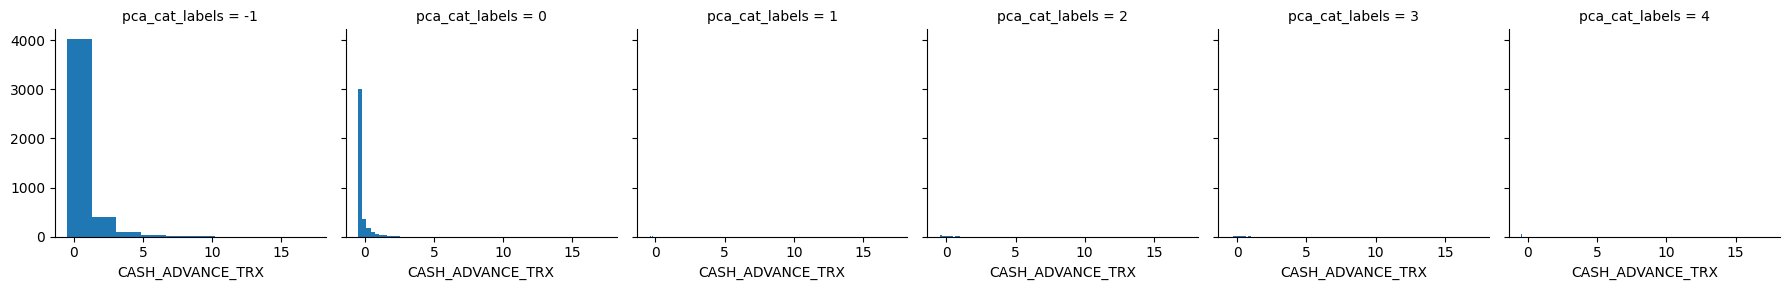

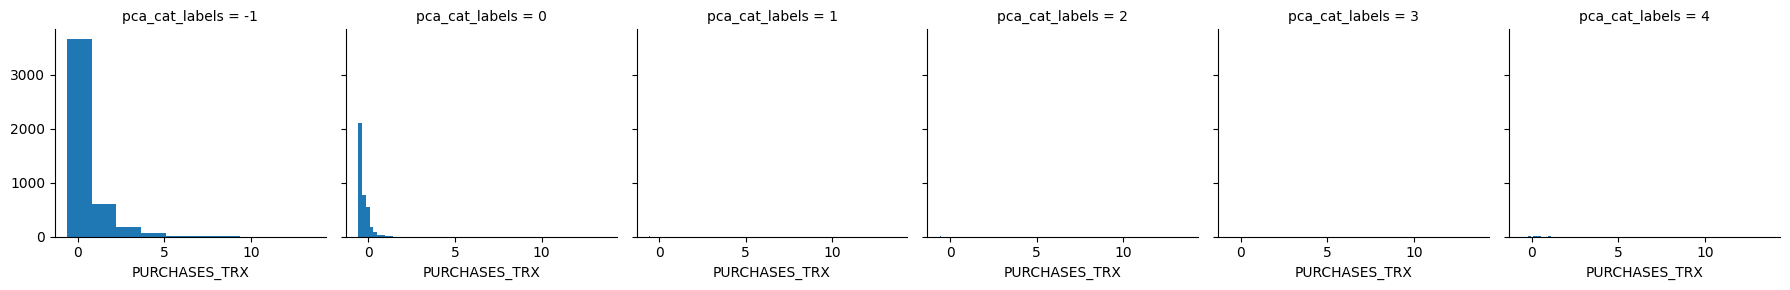

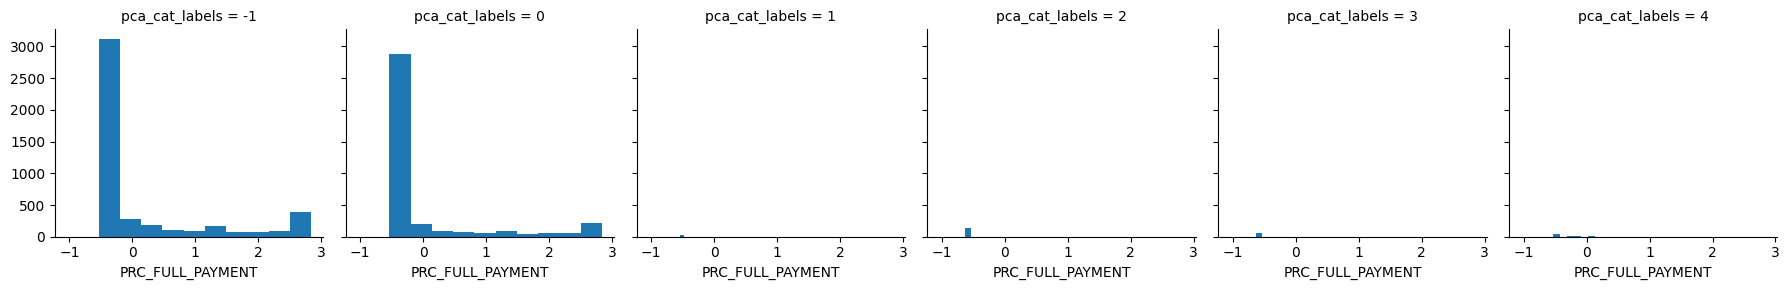

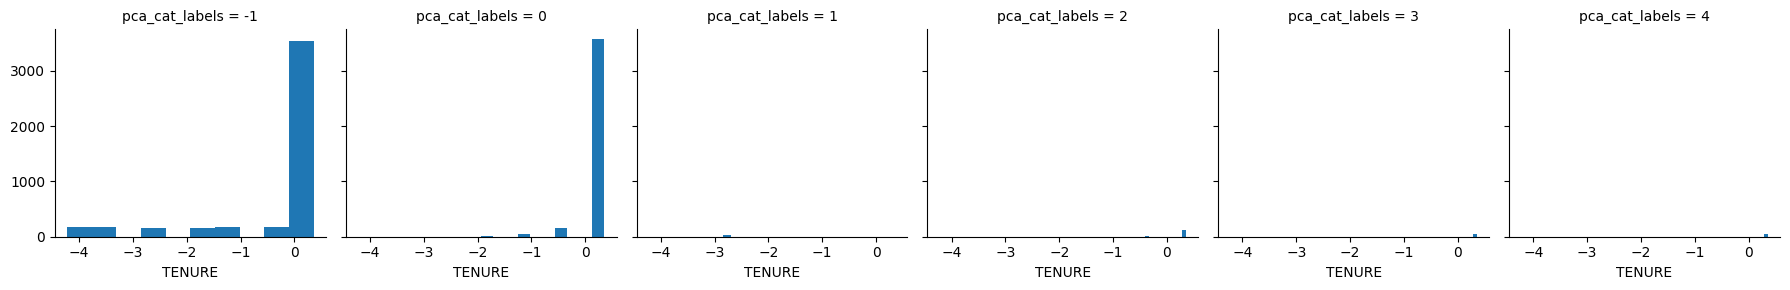

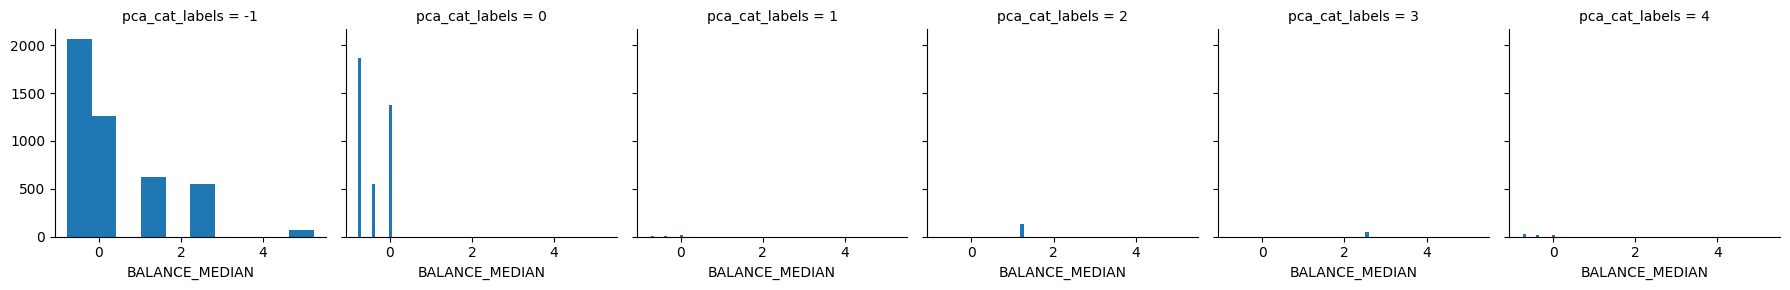

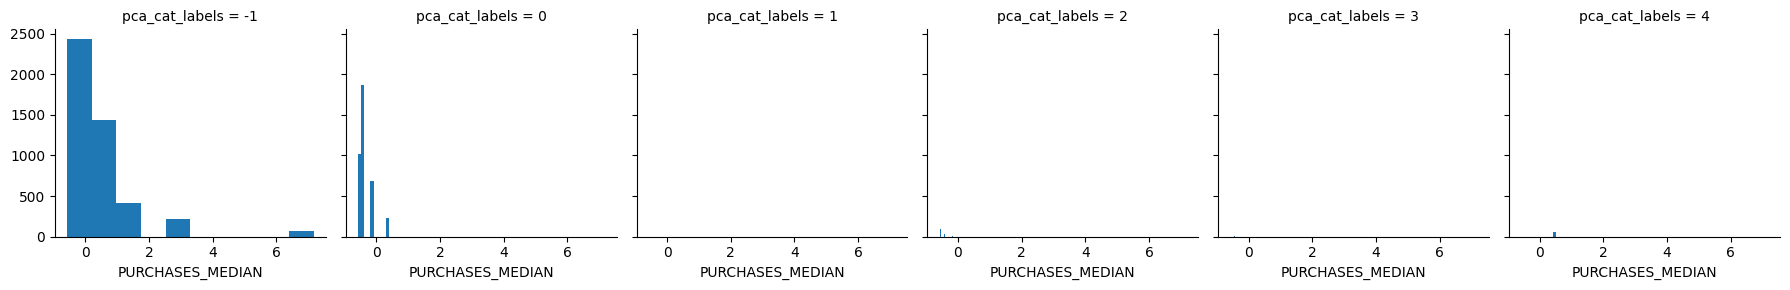

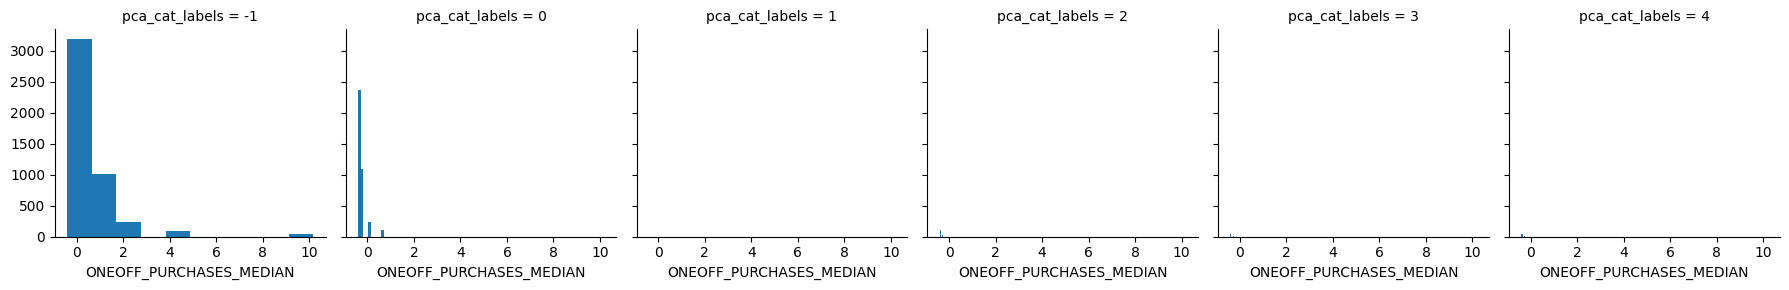

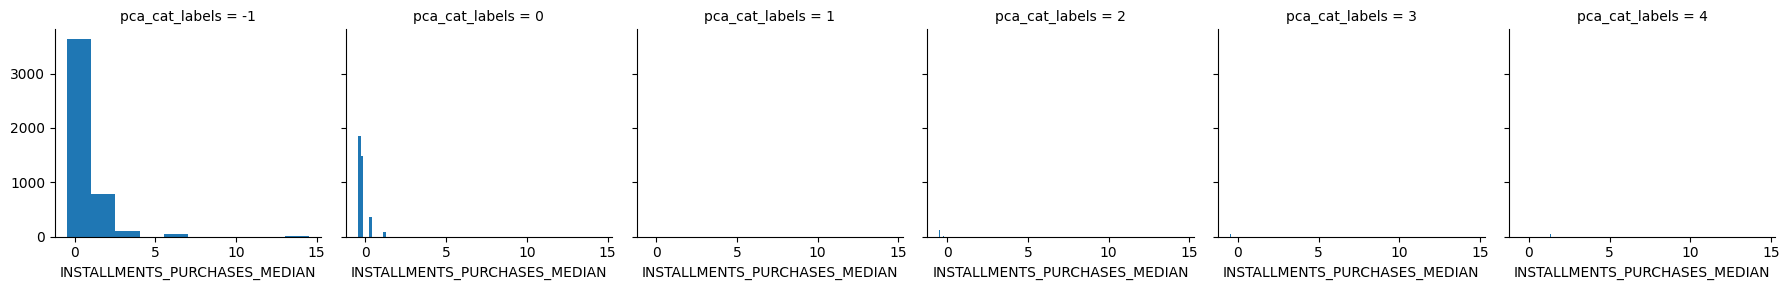

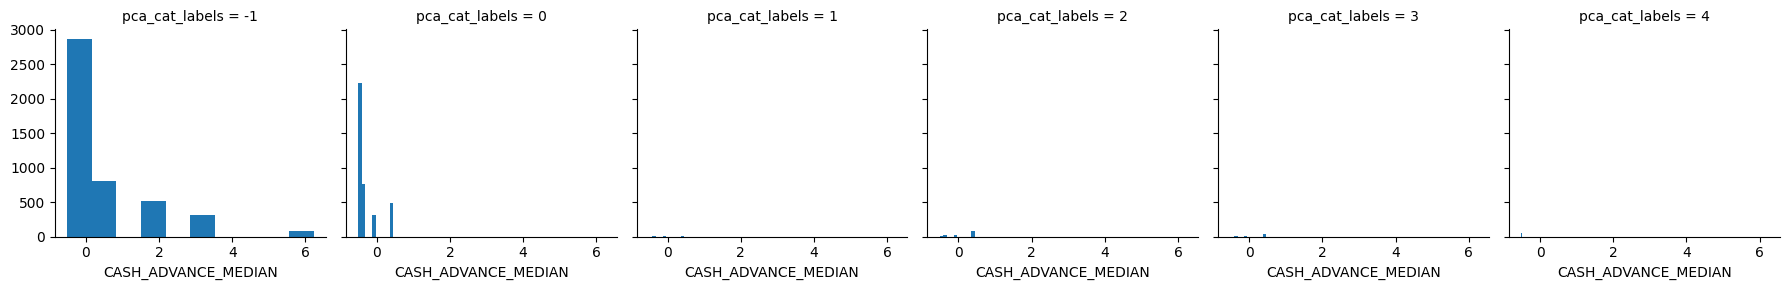

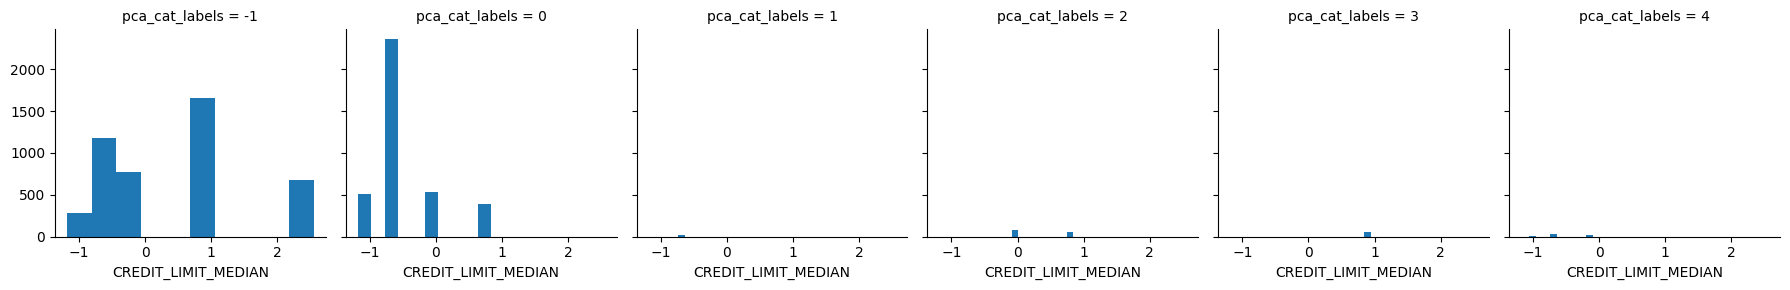

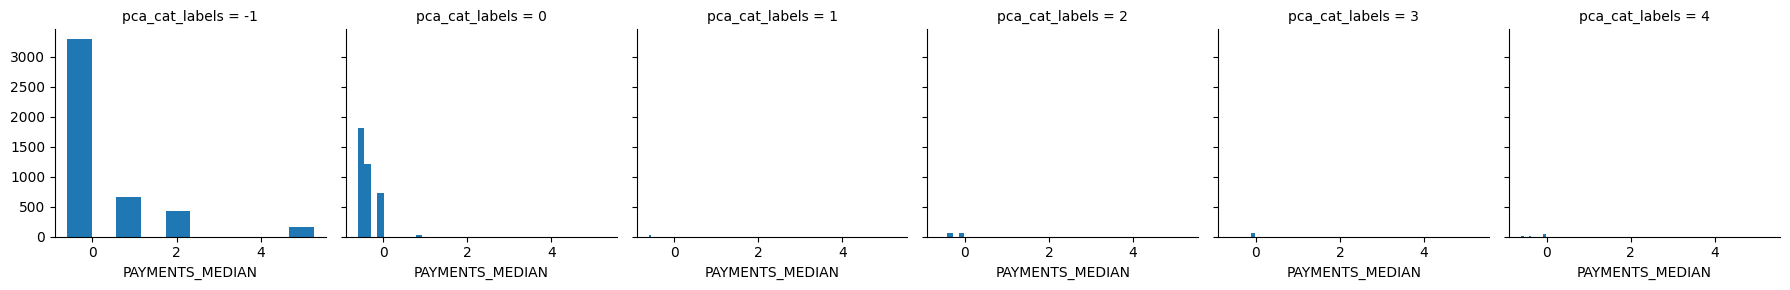

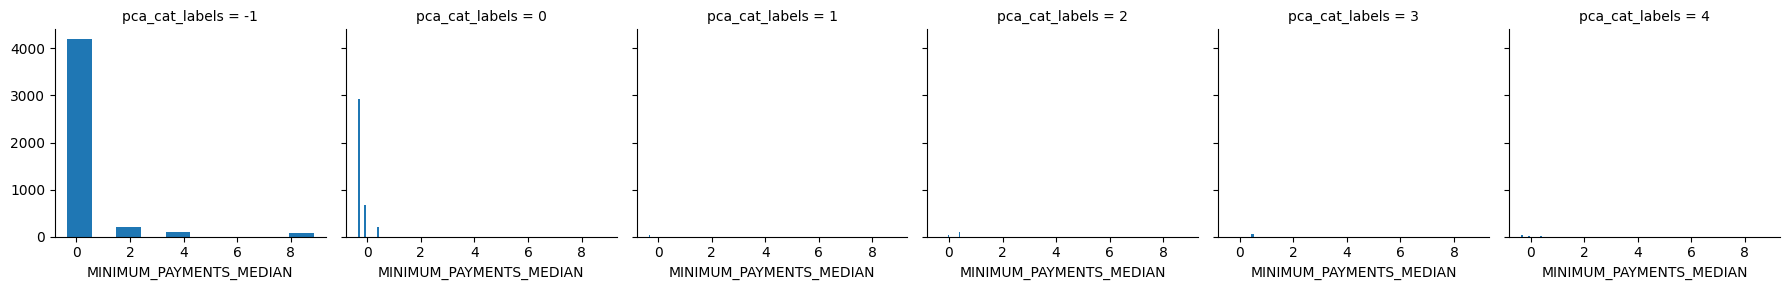

In [36]:
scaled_cat_df['pca_cat_labels'] = cluster_assignment
for c in scaled_cat_df.iloc[:,0:17]:
    grid= sns.FacetGrid(scaled_cat_df, col='pca_cat_labels')
    grid.map(plt.hist, c)

This is just one way of dealing with skewed data when performing cluster analysis. For example another approach would be to take a log transform of our data before scaling it. 